In [2]:
import numpy as np
from tqdm import tqdm
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from scipy.signal import hilbert
import numpy as np
sns.set_theme(style="whitegrid")

# Load Data

Samples to load: 44
  sample_name panel_name                                                                                                                                         ut_path                                                                                                                                       volfrac_path
0     Na_05_2      Na_05  /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/Na_05_2/registration_279/ut_volume.tif  /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/Na_05_2/registration_279/volfrac_maps.tif
1     Na_05_3      Na_05  /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/Na_05_3/registration_280/ut_volume.tif  /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/Na_05_3/registration_280/volfrac_maps.tif
2     Na_05_4      Na_05  /home/

Loading samples:   5%|▍         | 2/44 [00:00<00:02, 15.49it/s]

  Na_05_2              | total= 3315 | non-finite volfrac=-0 | negative volfrac=-78 | weak frontwall echo=-89 | border margin=-405 | bad volfrac in patch nbhd=-174 | volfrac above MAX_VOLFRAC cap=-2569 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.010 env_max=112.1
  Na_05_3              | total= 3315 | non-finite volfrac=-0 | negative volfrac=-124 | weak frontwall echo=-84 | border margin=-383 | bad volfrac in patch nbhd=-337 | volfrac above MAX_VOLFRAC cap=-2387 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.014 env_max=113.3
  Na_05_4              | total= 3315 | non-finite volfrac=-0 | negative volfrac=-79 | weak frontwall echo=-226 | border margin=-313 | bad volfrac in patch nbhd=-153 | volfrac above MAX_VOLFRAC cap=-2544 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.026 env_max=102.0


Loading samples:  14%|█▎        | 6/44 [00:00<00:02, 14.69it/s]

  Na_05_5              | total= 3360 | non-finite volfrac=-0 | negative volfrac=-114 | weak frontwall echo=-237 | border margin=-251 | bad volfrac in patch nbhd=-182 | volfrac above MAX_VOLFRAC cap=-2553 | valid=23 (0.7%) vf_min=-1.000 vf_max=0.052 env_max=102.7
  Na_06_1              | total= 3612 | non-finite volfrac=-0 | negative volfrac=-355 | weak frontwall echo=-127 | border margin=-168 | bad volfrac in patch nbhd=-436 | volfrac above MAX_VOLFRAC cap=-2526 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.035 env_max=112.6
  Na_06_2              | total= 3485 | non-finite volfrac=-0 | negative volfrac=-268 | weak frontwall echo=-100 | border margin=-222 | bad volfrac in patch nbhd=-354 | volfrac above MAX_VOLFRAC cap=-2541 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.018 env_max=112.9
  Na_06_3              | total= 3276 | non-finite volfrac=-0 | negative volfrac=-103 | weak frontwall echo=-92 | border margin=-373 | bad volfrac in patch nbhd=-195 | volfrac above MAX_VOLFRAC cap=-2513 | valid=0 

...

  Na_03_2              | total= 3698 | non-finite volfrac=-0 | negative volfrac=-418 | weak frontwall echo=-128 | border margin=-118 | bad volfrac in patch nbhd=-442 | volfrac above MAX_VOLFRAC cap=-2591 | valid=1 (0.0%) vf_min=-1.000 vf_max=0.005 env_max=109.7
  Na_03_3              | total= 3612 | non-finite volfrac=-0 | negative volfrac=-324 | weak frontwall echo=-122 | border margin=-162 | bad volfrac in patch nbhd=-398 | volfrac above MAX_VOLFRAC cap=-2606 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.010 env_max=109.8
  Na_03_4              | total= 3485 | non-finite volfrac=-0 | negative volfrac=-238 | weak frontwall echo=-215 | border margin=-213 | bad volfrac in patch nbhd=-251 | volfrac above MAX_VOLFRAC cap=-2568 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.009 env_max=101.1


Loading samples:  91%|█████████ | 40/44 [00:02<00:00, 14.95it/s]

  Na_03_5              | total= 3698 | non-finite volfrac=-0 | negative volfrac=-420 | weak frontwall echo=-217 | border margin=-116 | bad volfrac in patch nbhd=-351 | volfrac above MAX_VOLFRAC cap=-2594 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.071 env_max=102.2
  Na_04_1              | total= 3400 | non-finite volfrac=-0 | negative volfrac=-293 | weak frontwall echo=-88 | border margin=-283 | bad volfrac in patch nbhd=-457 | volfrac above MAX_VOLFRAC cap=-2279 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.032 env_max=107.3
  Na_04_2              | total= 3485 | non-finite volfrac=-0 | negative volfrac=-228 | weak frontwall echo=-167 | border margin=-206 | bad volfrac in patch nbhd=-303 | volfrac above MAX_VOLFRAC cap=-2579 | valid=2 (0.1%) vf_min=-1.000 vf_max=0.014 env_max=109.4
  Na_04_3              | total= 3400 | non-finite volfrac=-0 | negative volfrac=-135 | weak frontwall echo=-134 | border margin=-336 | bad volfrac in patch nbhd=-362 | volfrac above MAX_VOLFRAC cap=-2430 | valid=3 (

Loading samples: 100%|██████████| 44/44 [00:02<00:00, 14.88it/s]

  Na_04_4              | total= 3440 | non-finite volfrac=-0 | negative volfrac=-169 | weak frontwall echo=-218 | border margin=-231 | bad volfrac in patch nbhd=-264 | volfrac above MAX_VOLFRAC cap=-2558 | valid=0 (0.0%) vf_min=-1.000 vf_max=0.022 env_max=99.8
  Na_04_5              | total= 3567 | non-finite volfrac=-0 | negative volfrac=-391 | weak frontwall echo=-266 | border margin=-110 | bad volfrac in patch nbhd=-317 | volfrac above MAX_VOLFRAC cap=-2466 | valid=17 (0.5%) vf_min=-1.000 vf_max=0.041 env_max=98.4
  Na_05_1              | total= 3654 | non-finite volfrac=-0 | negative volfrac=-514 | weak frontwall echo=-71 | border margin=-127 | bad volfrac in patch nbhd=-711 | volfrac above MAX_VOLFRAC cap=-2230 | valid=1 (0.0%) vf_min=-1.000 vf_max=0.033 env_max=113.9
ut_patches shape : (51, 1, 1, 448)
volfrac shape    : (51,)
Panels           : ['Na_03' 'Na_04' 'Na_05' 'Na_08']

Discard summary across all panels (cascade order — each row only counts pixels not already discarded a

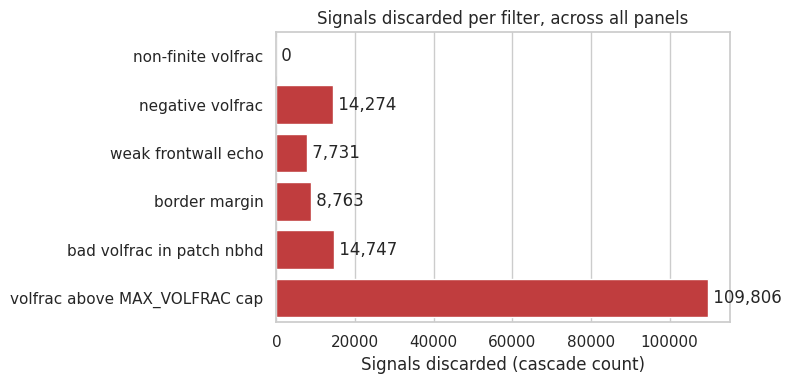

In [3]:
import ast
import tifffile
from scipy.ndimage import uniform_filter, maximum_filter

# ── Configuration (mirrors EDA notebook) ─────────────────────────────────────
MANIFEST_PATH = Path('/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/image_dataset_manifest.csv')
SAMPLE_NAME_FILTER = "Na"
PANELS_TO_EXCLUDE = ["Na_02"]
GLOBAL_ENVELOPE_MAX_THRESHOLD = 60.0
UT_ALIGNMENT_POINT = 50
# Crop indices are in ALIGNED signal space (frontwall fixed at index 50).
# Cropping is applied AFTER alignment — never before.
CROP_START = 0   # 1st-pct frontwall start − 10 (from EDA crop recommendations)
CROP_END = 500    # 99th-pct backwall end + 20  (from EDA crop recommendations)

patch_size = 1
VOLFRAC_PATCH_SIZE = 5 # side length of the square patch used to compute the mean volfrac target
MAX_VOLFRAC = 0      # upper cap on patch-mean volfrac; set to float to drop samples above this value (None = disabled)
OVERSAMPLE_TRAINING = False  # set False to train on the raw (skewed) volfrac distribution
z_resolution = 0.02232141

overwrite = False

# ── Load and filter manifest ──────────────────────────────────────────────────
PATH_PREFIX_OLD = '/home/alberto.vicente/phd'
PATH_PREFIX_NEW = '/host'

def _remap_path(p):
    if pd.isna(p):
        return p
    p = str(p)
    return p.replace(PATH_PREFIX_OLD, PATH_PREFIX_NEW, 1) if p.startswith(PATH_PREFIX_OLD) else p

manifest_df = pd.read_csv(MANIFEST_PATH)

# Apply the same panel filtering as EDA
manifest_df = manifest_df.loc[
    manifest_df['sample_name'].astype(str).str.contains(SAMPLE_NAME_FILTER, na=False)
].copy()
manifest_df = manifest_df.loc[
    ~manifest_df['panel_name'].isin(PANELS_TO_EXCLUDE)
].copy()

# Remap old path prefix (only needed when running inside the Docker container
# where the host's PATH_PREFIX_OLD tree is bind-mounted at PATH_PREFIX_NEW;
# no-op when running natively, since PATH_PREFIX_NEW won't exist)
if Path(PATH_PREFIX_NEW).is_dir():
    path_cols = [c for c in manifest_df.columns if c == 'image_path' or c.endswith('_path') or c.endswith('_path_raw')]
    for col in path_cols:
        manifest_df[col] = manifest_df[col].map(_remap_path)

# Pivot to one row per sample with ut_path / volfrac_path
sample_key_columns = ['sample_id', 'sample_name', 'panel_id', 'panel_name']
image_path_pivot = (
    manifest_df.pivot_table(
        index=sample_key_columns, columns='image_kind', values='image_path', aggfunc='first'
    )
    .rename(columns=lambda c: f'{c}_path')
    .reset_index()
)
sample_metadata_df = manifest_df[sample_key_columns].drop_duplicates(subset=sample_key_columns)
sample_asset_df = sample_metadata_df.merge(image_path_pivot, on=sample_key_columns, how='left')

print(f'Samples to load: {len(sample_asset_df)}')
print(sample_asset_df[['sample_name', 'panel_name', 'ut_path', 'volfrac_path']].head().to_string())

# ── Signal alignment helper (from EDA) ───────────────────────────────────────
def align_signals_by_frontwall(signal_matrix, alignment_point):
    signal_matrix = np.asarray(signal_matrix, dtype=np.float32)
    centered = signal_matrix - signal_matrix.mean(axis=1, keepdims=True)
    envelopes = np.abs(hilbert(centered, axis=1))
    frontwall_positions = np.argmax(envelopes, axis=1).astype(int)
    shifts = (int(alignment_point) - frontwall_positions).astype(int)
    aligned = np.empty_like(signal_matrix)
    for i, shift in enumerate(shifts):
        aligned[i] = np.roll(signal_matrix[i], shift)
    return aligned, frontwall_positions, shifts

# ── Pixel-rejection filters applied, in order, to build valid_mask ───────────
# Each stage below only sees pixels that survived every earlier stage, so the
# "discarded" count for a stage is exactly the number of *additional* pixels
# it removes (a pixel failing two criteria is attributed to whichever runs
# first). This cascade/funnel accounting is what makes per-filter discard
# counts additive and easy to read, instead of the previous overlapping
# base/border/sentinel counts that couldn't be summed.
FILTER_NAMES = [
    'non-finite volfrac',
    'negative volfrac',
    'weak frontwall echo',
    'border margin',
    'bad volfrac in patch nbhd',
    'volfrac above MAX_VOLFRAC cap',
]

# ── Load volumes, filter pixels, align, crop → flat arrays ───────────────────
all_signals   = []
all_volfrac   = []
all_ids       = []
all_panel_ids = []
panel_filter_stats = []   # per-panel discard counts, one row per filter stage

for _, row in tqdm(sample_asset_df.iterrows(), total=len(sample_asset_df), desc='Loading samples'):
  try:
    ut_volume      = tifffile.imread(row['ut_path'])           # (signal_len, n_rows, n_cols)
    volfrac_volume = tifffile.imread(row['volfrac_path'])      # (depth, n_rows, n_cols)

    ut_f32             = np.asarray(ut_volume, dtype=np.float32)
    ut_volume_centered = ut_f32 - ut_f32.mean(axis=0, keepdims=True)
    volfrac_f32        = np.asarray(volfrac_volume, dtype=np.float32)
    _volfrac_sentinel  = (volfrac_f32 == -1).any(axis=0)            # True where any depth slice is -1
    full_volfrac_map   = volfrac_f32.mean(axis=0)                   # (n_rows, n_cols)

    ut_envelope     = np.abs(hilbert(ut_volume_centered, axis=0))
    ut_envelope_max = ut_envelope.max(axis=0)
    n_total = full_volfrac_map.size

    # Target: mean of VOLFRAC_PATCH_SIZE×VOLFRAC_PATCH_SIZE neighbourhood centred on each pixel.
    # Computed here (before the filter cascade) because MAX_VOLFRAC filters on this
    # smoothed value, not on the raw per-pixel volfrac.
    volfrac_patch_mean = uniform_filter(full_volfrac_map, size=VOLFRAC_PATCH_SIZE, mode='reflect')

    # Border margin must be large enough for both the volfrac neighbourhood
    # and the UT spatial patch (when patch_size > 1).
    _pad = max(VOLFRAC_PATCH_SIZE // 2, patch_size // 2)
    _border_mask = np.zeros(full_volfrac_map.shape, dtype=bool)
    if _pad > 0:
        _border_mask[_pad:-_pad, _pad:-_pad] = True
    else:
        _border_mask[:] = True   # _pad==0: 1x1 neighbourhood fits everywhere

    _patch_has_bad_volfrac = maximum_filter(_volfrac_sentinel, size=VOLFRAC_PATCH_SIZE)

    if MAX_VOLFRAC is None:
        _mask_max_volfrac = np.ones(full_volfrac_map.shape, dtype=bool)
    else:
        _mask_max_volfrac = volfrac_patch_mean <= MAX_VOLFRAC

    _filter_masks = [
        np.isfinite(full_volfrac_map),          # non-finite volfrac
        full_volfrac_map >= 0,                  # negative volfrac (incl. -1 sentinel)
        ut_envelope_max >= GLOBAL_ENVELOPE_MAX_THRESHOLD,  # weak frontwall echo
        _border_mask,                           # border margin
        ~_patch_has_bad_volfrac,                # bad volfrac in patch nbhd
        _mask_max_volfrac,                      # volfrac above MAX_VOLFRAC cap
    ]

    _remaining = np.ones(full_volfrac_map.shape, dtype=bool)
    _discards = {}
    for _name, _m in zip(FILTER_NAMES, _filter_masks):
        _before = int(_remaining.sum())
        _remaining &= _m
        _discards[_name] = _before - int(_remaining.sum())

    valid_mask = _remaining
    n_valid = int(valid_mask.sum())

    panel_filter_stats.append({
        'sample_name': row['sample_name'],
        'total': n_total,
        **_discards,
        'valid': n_valid,
    })

    _discard_str = ' | '.join(f'{k}=-{v}' for k, v in _discards.items())
    print(
        f"  {row['sample_name']:20s} | total={n_total:5d} | {_discard_str} "
        f"| valid={n_valid} ({n_valid / n_total:.1%}) "
        f"vf_min={full_volfrac_map.min():.3f} vf_max={full_volfrac_map.max():.3f} "
        f"env_max={ut_envelope_max.max():.1f}"
    )

    if valid_mask.sum() == 0:
        continue

    signal_len_raw, n_rows, n_cols = ut_volume_centered.shape

    if patch_size == 1:
        # ── Single-pixel path (unchanged) ────────────────────────────────────
        signal_matrix = ut_volume_centered.reshape(signal_len_raw, -1).T  # (n_pixels, signal_len)
        valid_flat    = valid_mask.flatten()
        aligned, _, _ = align_signals_by_frontwall(signal_matrix[valid_flat], UT_ALIGNMENT_POINT)
        cropped = aligned[:, CROP_START:CROP_END]
        cropped = cropped[:, None, None, :]  # (n_valid, 1, 1, signal_len)

    else:
        # ── Patch path: extract patch_size×patch_size neighbourhood, align each
        #    signal individually, keep all → (n_valid, ps, ps, signal_len) ────────
        half = patch_size // 2
        valid_rows, valid_cols = np.where(valid_mask)

        r_offsets = np.arange(-half, half + 1)           # (patch_size,)
        c_offsets = np.arange(-half, half + 1)           # (patch_size,)
        r_grid, c_grid = np.meshgrid(r_offsets, c_offsets, indexing='ij')  # (ps, ps)

        # Index arrays: (n_valid, patch_size, patch_size)
        r_idx = valid_rows[:, None, None] + r_grid[None]
        c_idx = valid_cols[:, None, None] + c_grid[None]

        # Extract all patch signals at once: (signal_len, n_valid, ps, ps)
        patches_4d = ut_volume_centered[:, r_idx, c_idx]

        # Reshape for vectorised alignment: (n_valid * ps², signal_len)
        patches_flat = patches_4d.transpose(1, 2, 3, 0).reshape(n_valid * patch_size**2, -1)
        aligned_flat, _, _ = align_signals_by_frontwall(patches_flat, UT_ALIGNMENT_POINT)

        # Keep all patch signals → (n_valid, ps, ps, signal_len)
        patch_signals = aligned_flat.reshape(n_valid, patch_size, patch_size, -1)
        cropped = patch_signals[..., CROP_START:CROP_END]  # (n_valid, ps, ps, signal_len)
        valid_flat = valid_mask.flatten()

    all_signals.append(cropped.astype(np.float32))
    all_volfrac.append(volfrac_patch_mean.flatten()[valid_flat])
    all_ids.extend([row['sample_name']] * n_valid)
    all_panel_ids.extend([row['panel_name']] * n_valid)
  except Exception as _panel_err:
    print(f'  ✗ {row["sample_name"]}: {type(_panel_err).__name__}: {_panel_err}')
    continue

if not all_signals:
    raise RuntimeError(
        f'No valid signals collected from any of {len(sample_asset_df)} panels. '
        'Check the per-panel error messages above. Common causes: '
        'TIFF paths not found, GLOBAL_ENVELOPE_MAX_THRESHOLD too strict, or all volfrac sentinel.'
    )
ut_patches = np.concatenate(all_signals, axis=0).astype(np.float32)   # (N, ps, ps, signal_len)
volfrac    = np.concatenate(all_volfrac).astype(np.float32)  # (N,)
ids        = np.array(all_ids,       dtype=str)
panel_ids  = np.array(all_panel_ids, dtype=str)

print(f'ut_patches shape : {ut_patches.shape}')
print(f'volfrac shape    : {volfrac.shape}')
print(f'Panels           : {np.unique(panel_ids)}')

# ── Aggregate discard summary across all panels ───────────────────────────────
filter_stats_df = pd.DataFrame(panel_filter_stats).set_index('sample_name')

totals = filter_stats_df.sum(numeric_only=True)
n_total_pixels = totals['total']
summary_rows = []
for name in FILTER_NAMES:
    summary_rows.append({
        'filter': name,
        'discarded': int(totals[name]),
        'pct_of_total': totals[name] / n_total_pixels,
    })
summary_rows.append({
    'filter': 'valid (kept)',
    'discarded': int(totals['valid']),
    'pct_of_total': totals['valid'] / n_total_pixels,
})
discard_summary_df = pd.DataFrame(summary_rows)

print('\nDiscard summary across all panels (cascade order — each row only counts pixels not already discarded above it):')
print(discard_summary_df.to_string(index=False, formatters={'pct_of_total': '{:.1%}'.format}))
print(f"\nTotal pixels considered: {int(n_total_pixels)}  |  Total valid: {int(totals['valid'])} ({totals['valid']/n_total_pixels:.1%})")

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = discard_summary_df[discard_summary_df['filter'] != 'valid (kept)']
sns.barplot(data=plot_df, y='filter', x='discarded', ax=ax, color='tab:red')
for i, v in enumerate(plot_df['discarded']):
    ax.text(v, i, f' {v:,}', va='center')
ax.set_xlabel('Signals discarded (cascade count)')
ax.set_ylabel('')
ax.set_title('Signals discarded per filter, across all panels')
plt.tight_layout()
plt.show()

# Preprocessing

In [5]:
def hillbert_transform(volume):

    """
    This function applies the Hilbert transform to a 3D volume.
    
    Parameters:
    volume (numpy.ndarray): 3D array representing the volume of an image.
    
    Returns:
    numpy.ndarray: Amplitude envelope of the Hilbert transform.
    """

    volume = volume.astype(np.int16)

    volume = volume - volume.mean()

    data_hilbert = hilbert(volume, axis=-1)
    amplitude_envelope = np.abs(data_hilbert)

    return amplitude_envelope

def clean_reference_samples(ut_patches_amp, first_bin_idxs, frontwall_threshold, backwall_threshold):

    #first bin samples are the one with 0% volfrac, we will use them as reference samples
    ref_samples_amp = ut_patches_amp[first_bin_idxs, 0, 0]
    ref_idx = first_bin_idxs

    #but some of them may be corrupted, we will remove them

    #we will calculate the frontwall echoes and delete the ones that are too low
    frontwall_echoes = ref_samples_amp.max(axis=(-1))

    ref_idx = ref_idx[frontwall_echoes > frontwall_threshold]

    ref_samples_amp_front = ut_patches_amp[ref_idx, 0, 0]

    backwall_echoes = []

    distance = np.array([4.5,5.5]) #mm

    distance = distance / z_resolution #timesteps

    distance = np.round(distance).astype(np.uint16)

    for i,s in enumerate(ref_samples_amp_front):

        frontwall = np.argmax(s)

        if frontwall > 400:
            backwall_echoes.append(0)
            continue

        scan_area = distance + frontwall

        backwall_echoes.append(s[scan_area[0]:scan_area[1]].max())
    
    backwall_echoes = np.array(backwall_echoes)

    ref_idx = ref_idx[backwall_echoes > backwall_threshold]

    return ref_idx


def get_usefull_signals(ut_patches_amp, threshold=80):

    ut_patches_amp = ut_patches_amp.copy()[:, 0, 0]
    
    indexes = np.arange(ut_patches_amp.shape[0])

    print(len(indexes), 'signals before cleaning')

    #we will calculate the frontwall echoes and delete the ones that are too low
    frontwall_echoes = ut_patches_amp.max(axis=(-1))

    indexes = indexes[frontwall_echoes > threshold]

    print(len(indexes), 'signals after cleaning')

    return indexes

def convert_to_IQ(signal):
    """
    Convert a real-valued signal to its I/Q components using the Hilbert transform.
    Parameters:
    signal (np.ndarray): The input real-valued signal.
    Returns:
    I (np.ndarray): The in-phase component of the signal.
    Q (np.ndarray): The quadrature component of the signal.
    """

    # Get analytic signal (I + jQ)
    analytic_signal = hilbert(signal)
    I = np.real(analytic_signal)
    Q = np.imag(analytic_signal)

    return I, Q

def get_IQ_patch(ut_patch):
    """
    Convert a UT patch to its I/Q components.
    
    Parameters:
    ut_patch (np.ndarray): The input UT patch.
    
    Returns:
    np.ndarray: The I/Q components of the patch.
    """
    
    # Convert the patch to I/Q components
    I, Q = convert_to_IQ(ut_patch)

    # Stack I and Q components along a new axis
    iq_patch = np.stack((I, Q), axis=-1)

    return iq_patch

def get_IQ_patches(ut_patches):
    """
    Convert a set of UT patches to their I/Q components.
    Parameters:
    ut_patches_amp (np.ndarray): The input UT patches.
    Returns:
    np.ndarray: The I/Q components of the patches.
    """
    # Initialize an empty list to store the IQ patches
    iq_patches = []

    ut_patches = ut_patches - ut_patches.mean()

    # Loop through each patch and convert it to I/Q components
    for ut_patch in ut_patches:
        iq_patch = get_IQ_patch(ut_patch)
        iq_patches.append(iq_patch)

    # Convert the list of IQ patches to a numpy array
    iq_patches = np.array(iq_patches)

    return iq_patches

# Data stats

Frontwall peak: 50
Backwall gate : (200, 500)  (peak @ 254, amplitude=35.6213493347168)


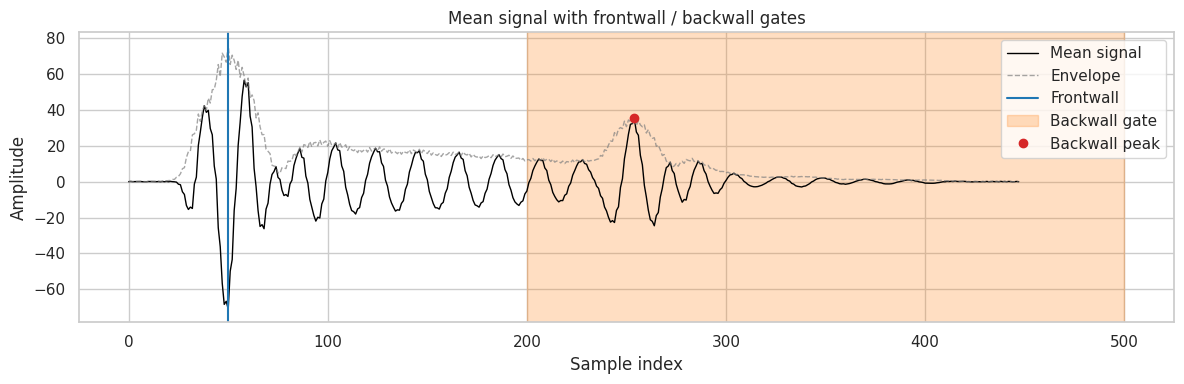

In [6]:
# ── Frontwall / Backwall gate definition ──────────────────────────────────
# Frontwall is simply the envelope's global peak (signals are aligned on it).
# The backwall gate is an explicit [start, end) window on the amplitude
# envelope of the mean signal; within it we report the maximum-amplitude
# point, provided it exceeds a minimum-amplitude threshold.

BACKWALL_GATE_START = 200   # index (cropped signal space) where the backwall gate opens
BACKWALL_GATE_END   = 500   # index (cropped signal space) where the backwall gate closes
BACKWALL_MIN_AMPLITUDE = 15  # minimum envelope amplitude required inside the gate

mean_signal   = ut_patches[:, 0, 0, :].mean(axis=0)                  # (signal_len,)
mean_envelope = np.abs(hilbert(mean_signal - mean_signal.mean()))

frontwall_peak = int(np.argmax(mean_envelope))

def backwall_gate(envelope, start, end, min_amplitude):
    """
    Locate the backwall echo on an amplitude envelope.

    Parameters:
    envelope (np.ndarray): amplitude envelope of the signal (1D).
    start, end (int): sample-index limits of the gate (end exclusive).
    min_amplitude (float): minimum amplitude the peak must reach inside the
        gate to be considered a valid backwall echo.

    Returns:
    (peak_idx, peak_value): index (in envelope's coordinates) and amplitude
        of the maximum point inside [start, end). Returns (None, None) if
        the gate is empty or no point inside it reaches min_amplitude.
    """
    start = max(start, 0)
    end   = min(end, len(envelope))
    segment = envelope[start:end]

    if segment.size == 0:
        return None, None

    peak_local = int(np.argmax(segment))
    peak_value = float(segment[peak_local])

    if peak_value < min_amplitude:
        return None, None

    return start + peak_local, peak_value

backwall_peak, backwall_value = backwall_gate(
    mean_envelope, BACKWALL_GATE_START, BACKWALL_GATE_END, BACKWALL_MIN_AMPLITUDE
)

BACKWALL_GATE = (BACKWALL_GATE_START, BACKWALL_GATE_END)

print(f'Frontwall peak: {frontwall_peak}')
print(f'Backwall gate : {BACKWALL_GATE}  (peak @ {backwall_peak}, amplitude={backwall_value})')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mean_signal, color='black', linewidth=1, label='Mean signal')
ax.plot(mean_envelope, color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Envelope')

ax.axvline(frontwall_peak, color='tab:blue', linewidth=1.5, label='Frontwall')
ax.axvspan(*BACKWALL_GATE, color='tab:orange', alpha=0.25, label='Backwall gate')
if backwall_peak is not None:
    ax.plot(backwall_peak, backwall_value, 'o', color='tab:red', label='Backwall peak')

ax.set_xlabel('Sample index')
ax.set_ylabel('Amplitude')
ax.set_title('Mean signal with frontwall / backwall gates')
ax.legend()
plt.tight_layout()
plt.show()

21 / 51 signals have a backwall amplitude >= 50


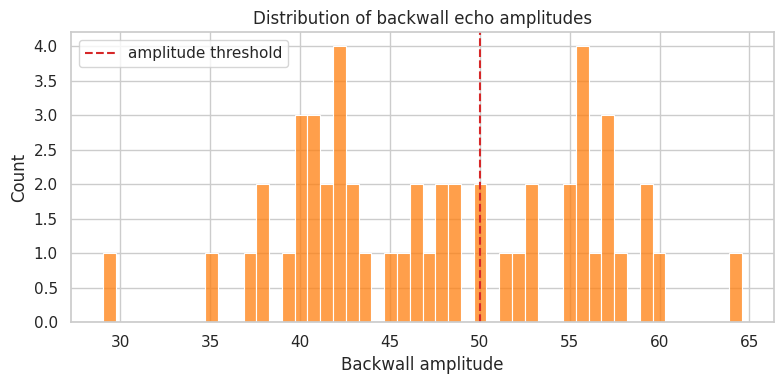

In [7]:
# ── Backwall amplitude distribution across all signals ──────────────────────
# Same gate window as above (BACKWALL_GATE_START/END), applied per-signal
# instead of just to the mean signal. BACKWALL_AMPLITUDE_THRESHOLD is set
# here for visual calibration against the full (unfiltered) distribution.

BACKWALL_AMPLITUDE_THRESHOLD = 50  # candidate minimum backwall amplitude

centered_signals = ut_patches[:, 0, 0, :] - ut_patches[:, 0, 0, :].mean(axis=1, keepdims=True)
envelopes = np.abs(hilbert(centered_signals, axis=-1))

gate_segment = envelopes[:, BACKWALL_GATE_START:BACKWALL_GATE_END]
backwall_amplitudes = gate_segment.max(axis=-1)

n_above = int((backwall_amplitudes >= BACKWALL_AMPLITUDE_THRESHOLD).sum())
print(
    f'{n_above} / {len(backwall_amplitudes)} signals have a backwall amplitude '
    f'>= {BACKWALL_AMPLITUDE_THRESHOLD}'
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(backwall_amplitudes, bins=50, ax=ax, color='tab:orange')
ax.axvline(BACKWALL_AMPLITUDE_THRESHOLD, color='tab:red', linestyle='--', label='amplitude threshold')
ax.set_xlabel('Backwall amplitude')
ax.set_ylabel('Count')
ax.set_title('Distribution of backwall echo amplitudes')
ax.legend()
plt.tight_layout()
plt.show()

21 / 51 signals kept (backwall amplitude >= 50)
panel_name  total  kept  discarded
     Na_03      1     1          0
     Na_04     22     1         21
     Na_05     24    16          8
     Na_08      4     3          1


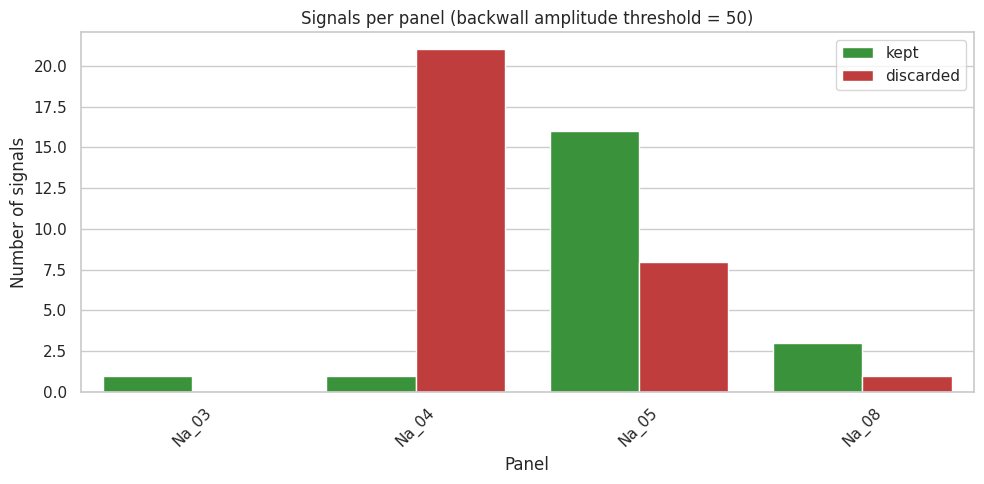

In [8]:
# ── Signals per panel, before/after backwall amplitude threshold ────────────
# A signal is discarded if its backwall amplitude (computed above) is lower
# than BACKWALL_AMPLITUDE_THRESHOLD.

backwall_keep_mask = backwall_amplitudes >= BACKWALL_AMPLITUDE_THRESHOLD

panel_counts_total = pd.Series(panel_ids).value_counts().sort_index()
panel_counts_kept  = pd.Series(panel_ids[backwall_keep_mask]).value_counts().reindex(panel_counts_total.index, fill_value=0)

panel_counts_df = pd.DataFrame({
    'total': panel_counts_total,
    'kept':  panel_counts_kept,
}).reset_index(names='panel_name')
panel_counts_df['discarded'] = panel_counts_df['total'] - panel_counts_df['kept']

print(
    f'{int(panel_counts_kept.sum())} / {len(backwall_amplitudes)} signals kept '
    f'(backwall amplitude >= {BACKWALL_AMPLITUDE_THRESHOLD})'
)
print(panel_counts_df.to_string(index=False))

plot_df = panel_counts_df.melt(
    id_vars='panel_name', value_vars=['kept', 'discarded'],
    var_name='status', value_name='count'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_df, x='panel_name', y='count', hue='status',
    palette={'kept': 'tab:green', 'discarded': 'tab:red'}, ax=ax
)
ax.set_xlabel('Panel')
ax.set_ylabel('Number of signals')
ax.set_title(f'Signals per panel (backwall amplitude threshold = {BACKWALL_AMPLITUDE_THRESHOLD})')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='')
plt.tight_layout()
plt.show()

# Reference signal dataset

In [9]:
# ── Build the reference-signal dataset ───────────────────────────────────────
# Reference signals are those that passed the backwall-amplitude filter above
# (backwall_keep_mask). The dataset is a DataFrame with one row per reference
# signal, carrying the same per-sample metadata columns as sample_asset_df
# (sample_id, sample_name, panel_id, panel_name, ut_path, volfrac_path),
# plus the signal itself and its volfrac target.

_sample_meta_cols = sample_key_columns + ['ut_path', 'volfrac_path']

reference_signal_df = pd.DataFrame({
    'sample_name': ids[backwall_keep_mask],
    'panel_name':  panel_ids[backwall_keep_mask],
    'volfrac':     volfrac[backwall_keep_mask],
})

if patch_size == 1:
    # (n_ref, signal_len) — one 1D signal per reference sample
    reference_signal_df['signal'] = list(ut_patches[backwall_keep_mask, 0, 0, :])
else:
    # (n_ref, ps, ps, signal_len) patch kept intact per reference sample
    reference_signal_df['signal'] = list(ut_patches[backwall_keep_mask])

reference_signal_df = reference_signal_df.merge(
    sample_asset_df[_sample_meta_cols], on=['sample_name', 'panel_name'], how='left'
)

# Reorder so sample metadata comes first, then the signal-level fields
reference_signal_df = reference_signal_df[_sample_meta_cols + ['signal', 'volfrac']]

print(f'reference_signal_df shape : {reference_signal_df.shape}')
print(f'Reference signals         : {len(reference_signal_df)} / {len(ids)} '
      f'({len(reference_signal_df) / len(ids):.1%})')
print(f"Panels                    : {reference_signal_df['panel_name'].unique()}")
reference_signal_df.head()

reference_signal_df shape : (21, 8)
Reference signals         : 21 / 51 (41.2%)
Panels                    : <ArrowStringArray>
['Na_05', 'Na_08', 'Na_03', 'Na_04']
Length: 4, dtype: str


,sample_id,sample_name,panel_id,panel_name,ut_path,volfrac_path,signal,volfrac
0,76,Na_05_5,9,Na_05,/home/alberto.vicente/phd/DataDriven_UT_Albert...,/home/alberto.vicente/phd/DataDriven_UT_Albert...,"[-0.30134583, 0.6986542, -0.30134583, -0.30134...",0.0
1,76,Na_05_5,9,Na_05,/home/alberto.vicente/phd/DataDriven_UT_Albert...,/home/alberto.vicente/phd/DataDriven_UT_Albert...,"[0.7276764, -0.2723236, 0.7276764, -0.2723236,...",0.0
2,76,Na_05_5,9,Na_05,/home/alberto.vicente/phd/DataDriven_UT_Albert...,/home/alberto.vicente/phd/DataDriven_UT_Albert...,"[-0.2901764, 0.7098236, -0.2901764, 0.7098236,...",0.0
3,76,Na_05_5,9,Na_05,/home/alberto.vicente/phd/DataDriven_UT_Albert...,/home/alberto.vicente/phd/DataDriven_UT_Albert...,"[0.7299042, -0.27009583, 0.7299042, -0.2700958...",0.0
4,76,Na_05_5,9,Na_05,/home/alberto.vicente/phd/DataDriven_UT_Albert...,/home/alberto.vicente/phd/DataDriven_UT_Albert...,"[-0.2566986, -0.2566986, -0.2566986, -0.256698...",0.0


In [10]:
save_path = Path('/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/Reference Signals')

In [11]:
# ── Save reference-signal dataset ────────────────────────────────────────────
save_path.mkdir(parents=True, exist_ok=True)
output_file = save_path / 'reference_signal_df.parquet'

if output_file.exists() and not overwrite:
    raise FileExistsError(
        f'{output_file} already exists and overwrite=False. '
        'Set overwrite=True to replace it.'
    )

# Parquet instead of pickle: portable across numpy/pandas versions (numpy 2.x pickles
# reference numpy._core and cannot be loaded under numpy 1.x). Signals are stored as
# nested lists; convert back with np.asarray(...) after pd.read_parquet.
reference_signal_df.assign(
    signal=reference_signal_df['signal'].map(lambda s: np.asarray(s).tolist())
).to_parquet(output_file, index=False)
print(f'Saved reference_signal_df {reference_signal_df.shape} to {output_file}')


Saved reference_signal_df (21, 8) to /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/Reference Signals/reference_signal_df.pkl


# Load to database

In [12]:
# ── Database imports ──────────────────────────────────────────────────────
# preprocess_tools is a local package (not pip-installed); add the repo root
# to sys.path the same way datasetmaker_images.ipynb does.
import sys
project_root = r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/10_code/UTvsXCT-preprocessing'
if project_root not in sys.path:
    sys.path.append(project_root)

from preprocess_tools import datasetmaker
from dbtools import dbtools as db
from dbtools import load as load

datasettype = 9              # "2026 reference signal dataset" (see datasettypes table)
SOURCE_DATASETTYPE_ID = 7    # datasettype of the per-registration image datasets this one is built from
load_into_database = True

In [13]:
# ── Connect to the database ───────────────────────────────────────────────
try:
    conn = db.connect()
    print("Connected to the database")
except Exception as error:
    print(error)

Connected to the database


In [14]:
# ── Duplicate guard ────────────────────────────────────────────────────────
# datasets.file_path is UNIQUE and load_dataset() swallows the resulting
# error internally (rollback, returns -1) rather than raising, so check first.
all_datasets_df = db.get_data('datasets')
already_loaded = bool((all_datasets_df['file_path_dataset'] == str(output_file)).any())

print(f'Already registered in the database: {already_loaded}')

Already registered in the database: False


In [18]:
# ── Resolve the samples that actually contributed a reference signal, and the
#    source (per-registration) datasets they came from ───────────────────────
contributing_samples_df = (
    reference_signal_df[['sample_id', 'sample_name', 'panel_id', 'panel_name']]
    .drop_duplicates()
    .sort_values('sample_name')
    .reset_index(drop=True)
)

_registration_lookup = manifest_df.drop_duplicates('sample_id').set_index('sample_id')['registration_id']
contributing_samples_df['registration_id'] = (
    contributing_samples_df['sample_id'].map(_registration_lookup).astype(int)
)

# Match against the child (datasettype 7) datasets already registered for these registrations.
child_datasets_df = all_datasets_df[all_datasets_df['datasettype_id_dataset'] == SOURCE_DATASETTYPE_ID].copy()
child_datasets_df['registration_id'] = (
    child_datasets_df['file_path_dataset']
    .str.extract(r'registration_(\d+)/image_manifest\.csv$')
    .astype(float)
)

contributing_samples_df = contributing_samples_df.merge(
    child_datasets_df[['registration_id', 'id_dataset', 'file_path_dataset']]
    .rename(columns={'id_dataset': 'source_dataset_id', 'file_path_dataset': 'source_dataset_path'}),
    on='registration_id', how='left',
)

_missing = contributing_samples_df[contributing_samples_df['source_dataset_id'].isna()]
if len(_missing):
    raise RuntimeError(
        f'Could not resolve a source (datasettype {SOURCE_DATASETTYPE_ID}) dataset for these samples:\n'
        f'{_missing[["sample_name", "registration_id"]].to_string(index=False)}'
    )
contributing_samples_df['source_dataset_id'] = contributing_samples_df['source_dataset_id'].astype(int)

# The parent manifest dataset all the per-registration datasets were grouped under.
_parent_dataset_row = all_datasets_df[all_datasets_df['file_path_dataset'] == str(MANIFEST_PATH)]
if len(_parent_dataset_row) > 1:
    raise RuntimeError(
        f'Expected at most one parent dataset row for {MANIFEST_PATH}, found {len(_parent_dataset_row)}'
    )
# The global image_dataset_manifest.csv is a plain CSV and is not necessarily registered in the DB.
source_parent_dataset_id = int(_parent_dataset_row['id_dataset'].iloc[0]) if len(_parent_dataset_row) else None
if source_parent_dataset_id is None:
    print(f'WARNING: parent manifest {MANIFEST_PATH} is not registered in the database; source_parent_dataset_id omitted')

print(f'Contributing samples : {len(contributing_samples_df)}')
print(f'Source parent dataset: id {source_parent_dataset_id} ({MANIFEST_PATH})')
print(contributing_samples_df[['sample_name', 'panel_name', 'registration_id', 'source_dataset_id']].to_string(index=False))

Contributing samples : 5
Source parent dataset: id None (/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/image_dataset_manifest.csv)
sample_name panel_name  registration_id  source_dataset_id
    Na_03_2      Na_03              269               1197
    Na_04_3      Na_04              275               1203
    Na_05_1      Na_05              278               1206
    Na_05_5      Na_05              282               1161
    Na_08_2      Na_08              293               1172


In [19]:
# ── UT / XCT patch sizes ──────────────────────────────────────────────────
# The notebook only defines the UT-side patch (patch_size, VOLFRAC_PATCH_SIZE,
# in UT pixels). Derive the XCT-grid equivalent with the same helper used by
# the image dataset notebooks, rather than hardcoding the resolution ratio.
ut_resolution = float(manifest_df['ut_resolution'].dropna().iloc[0])
xct_resolution = float(manifest_df['xct_resolution'].dropna().iloc[0])

xct_patch_size = int(round(datasetmaker.calculate_pixels(ut_resolution, xct_resolution, patch_size)))
xct_volfrac_patch_size = int(round(
    datasetmaker.calculate_pixels(ut_resolution, xct_resolution, VOLFRAC_PATCH_SIZE)
))

print(f'ut_resolution           : {ut_resolution} mm/pixel')
print(f'xct_resolution          : {xct_resolution} mm/pixel')
print(f'ut_patch_size           : {patch_size} UT px  ->  xct_patch_size           : {xct_patch_size} XCT px')
print(f'volfrac_patch_size (UT) : {VOLFRAC_PATCH_SIZE} UT px  ->  xct_volfrac_patch_size   : {xct_volfrac_patch_size} XCT px')

ut_resolution           : 1.0 mm/pixel
xct_resolution          : 0.025 mm/pixel
ut_patch_size           : 1 UT px  ->  xct_patch_size           : 40 XCT px
volfrac_patch_size (UT) : 5 UT px  ->  xct_volfrac_patch_size   : 200 XCT px


In [20]:
# ── Build additional_metadata ─────────────────────────────────────────────
# Same idiom as load_image_datasets_to_database.ipynb: each item becomes one
# row in dataset_metadata (key, value, type); value is always stringified.
def metadata_item(key, value, metadata_type):
    if value is None:
        return None
    if isinstance(value, float) and pd.isna(value):
        return None
    return {'key': key, 'value': str(value), 'type': metadata_type}


signal_len = int(len(reference_signal_df['signal'].iloc[0]))

additional_metadata = [
    # ── Filters used to select reference signals (datasettype 9 definition) ──
    metadata_item('GLOBAL_ENVELOPE_MAX_THRESHOLD', GLOBAL_ENVELOPE_MAX_THRESHOLD, 'amplitude'),
    metadata_item('UT_ALIGNMENT_POINT', UT_ALIGNMENT_POINT, 'pixels'),
    metadata_item('MAX_VOLFRAC', MAX_VOLFRAC, 'ratio'),
    metadata_item('BACKWALL_GATE_START', BACKWALL_GATE_START, 'pixels'),
    metadata_item('BACKWALL_GATE_END', BACKWALL_GATE_END, 'pixels'),
    metadata_item('BACKWALL_MIN_AMPLITUDE', BACKWALL_MIN_AMPLITUDE, 'amplitude'),
    metadata_item('BACKWALL_AMPLITUDE_THRESHOLD', BACKWALL_AMPLITUDE_THRESHOLD, 'amplitude'),

    # ── UT / XCT patch sizes ──────────────────────────────────────────────────
    metadata_item('ut_patch_size', patch_size, 'pixels'),
    metadata_item('xct_patch_size', xct_patch_size, 'pixels'),
    metadata_item('ut_patch_size_mm', patch_size * ut_resolution, 'mm'),
    metadata_item('xct_patch_size_mm', xct_patch_size * xct_resolution, 'mm'),
    metadata_item('volfrac_patch_size', VOLFRAC_PATCH_SIZE, 'pixels'),
    metadata_item('xct_volfrac_patch_size', xct_volfrac_patch_size, 'pixels'),
    metadata_item('ut_resolution', ut_resolution, 'mm/pixel'),
    metadata_item('xct_resolution', xct_resolution, 'mm/pixel'),

    # ── Supporting provenance for the stored signal ─────────────────────────
    metadata_item('CROP_START', CROP_START, 'pixels'),
    metadata_item('CROP_END', CROP_END, 'pixels'),
    metadata_item('SAMPLE_NAME_FILTER', SAMPLE_NAME_FILTER, 'nominal'),
    metadata_item('PANELS_TO_EXCLUDE', tuple(PANELS_TO_EXCLUDE), 'nominal tuple'),
    metadata_item('signal_length', signal_len, 'pixels'),
    metadata_item('n_samples', int(contributing_samples_df['sample_id'].nunique()), 'cardinal'),
    metadata_item('n_panels', int(contributing_samples_df['panel_id'].nunique()), 'cardinal'),

    # ── Source dataset paths ─────────────────────────────────────────────────
    metadata_item('source_parent_manifest_path', str(MANIFEST_PATH), 'path'),
    metadata_item('source_parent_dataset_id', source_parent_dataset_id, 'cardinal'),
    metadata_item('source_dataset_count', len(contributing_samples_df), 'cardinal'),
]

for _, _row in contributing_samples_df.iterrows():
    additional_metadata.append(metadata_item('source_dataset_path', _row['source_dataset_path'], 'path'))
    additional_metadata.append(metadata_item('source_dataset_id', int(_row['source_dataset_id']), 'cardinal'))

additional_metadata = [m for m in additional_metadata if m is not None]
print(f'{len(additional_metadata)} additional_metadata items built')

34 additional_metadata items built


In [21]:
# ── Insert the dataset row ────────────────────────────────────────────────
if not load_into_database or datasettype is None:
    print('load_into_database is False; skipping database insert.')
elif already_loaded:
    print(f'{output_file} is already registered in the database; skipping insert.')
else:
    reference_registration_ids = [int(r) for r in contributing_samples_df['registration_id']]

    dataset_id = load.load_dataset(
        conn,
        datasettype_id=int(datasettype),
        file_path=str(output_file),
        rows=int(len(reference_signal_df)),
        patch_size=str(patch_size),
        targets=['volfrac'],
        reconstruction_shape=(int(len(reference_signal_df)), signal_len),
        registration_ids=reference_registration_ids,
        description=(
            '2026 reference signal dataset. Pore-free A-scans (volfrac == 0) selected from the '
            'Hexcel 2026 5MHz image datasets, frontwall-aligned at index 50. '
            'Stored as a parquet file with one row per reference signal (signal column as nested lists).'
        ),
        additional_metadata=additional_metadata,
    )

    if dataset_id == -1:
        raise RuntimeError('load_dataset failed (see printed error above); no rows were committed.')

    print(f'dataset_id: {dataset_id}')

Dataset from '/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/Reference Signals/reference_signal_df.pkl' loaded with ID: 1294
dataset_id: 1294


In [22]:
# ── Verify the insert ──────────────────────────────────────────────────────
# Run after the insert cell above to confirm the row, its metadata and its
# registration links landed as expected.
if 'dataset_id' in dir() and dataset_id != -1:
    dataset_metadata_df = db.get_data('dataset_metadata')
    inserted_metadata_df = dataset_metadata_df[
        dataset_metadata_df['dataset_id_dataset_metadat'] == dataset_id
    ]
    print(f'dataset_metadata rows for dataset {dataset_id}: {len(inserted_metadata_df)}')
    print(inserted_metadata_df[['key_dataset_metadat', 'value_dataset_metadat', 'type_dataset_metadat']].to_string(index=False))

    dataset_registrations_df = db.relation_metadata('datasets', 'registrations', 'dataset_registrations')
    n_linked = len(dataset_registrations_df[dataset_registrations_df['id_dataset'] == dataset_id])
    print(f'\nRegistrations linked: {n_linked} (expected {len(contributing_samples_df)})')

    roundtrip_df = pd.read_parquet(output_file)
    print(f'Round-trip parquet shape: {roundtrip_df.shape} (expected {reference_signal_df.shape})')
else:
    print('No dataset_id to verify (insert was skipped or failed).')

dataset_metadata rows for dataset 1294: 38
          key_dataset_metadat                                                                                                                 value_dataset_metadat type_dataset_metadat
                         rows                                                                                                                                    21             cardinal
                   patch_size                                                                                                                                     1               pixels
         reconstruction_shape                                                                                                                             (21, 448)         pixels tuple
GLOBAL_ENVELOPE_MAX_THRESHOLD                                                                                                                                  60.0            amplitude
           UT_ALIGNMENT_POINT   

In [ ]:
import pandas as pd, numpy as np
src = '/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/04_ML_data/Airbus/Hexcel/2026/5MHz_FedeOnlypores/Reference Signals/reference_signal_df.pkl'
df = pd.read_pickle(src)
df['signal'] = df['signal'].map(lambda s: np.asarray(s).tolist())
df.to_parquet(src.replace('.pkl', '.parquet'))